# 문서 유사도 (Document Similarity)
- 두 문서가 내용적으로 얼마나 비슷한지를 수치로 나타낸다.
- 보통 문서를 벡터(TF-IDF 등) 로 바꾼 뒤, 벡터 간 유사도를 구한다.

In [15]:
import numpy as np
import pandas as pd
import os, glob  # 운영체제 조작(경로 처리)  /  파일 패턴 검색

path = './data/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path, '*.data'))  # 해당하는 경로에 있는 파일명 중 .data로 된 데이터 파일 목록을 수집

filename_list = []  # 파일명
opinions_list = []  # 파일내용 (의견)

for file_ in all_files:
    df = pd.read_table( 
        file_,              # 경로
        header=None,        # 첫 줄은 컬럼명으로 사용 (안함)
        index_col=None,     # 인덱스 컬럼 지정 (안함) (기본생성)
        encoding='latin1'   # 특수문자 깨짐 방지
    )
    # display(df)

    filename = os.path.basename(file_)  # 파일명 추출
    filename = filename.split('.')[0]   # 확장자 제거(하고 순수한 파일명만)
    filename_list.append(filename)      # 추출한 순수한 파일명들을 리스트에 추가

    opinions = df.to_string(index=False, header=False)  # 인덱스 / 헤더 제거
    opinions_list.append(opinions)

In [16]:
document_df = pd.DataFrame({
    'filename' : filename_list,
    'opinions' : opinions_list
})

document_df

,filename,opinions
0,accuracy_garmin_nuvi_255W_gps,...
1,bathroom_bestwestern_hotel_sfo,...
2,battery-life_amazon_kindle,...
3,battery-life_ipod_nano_8gb,...
4,battery-life_netbook_1005ha,...
5,buttons_amazon_kindle,...
6,comfort_honda_accord_2008,...
7,comfort_toyota_camry_2007,...
8,directions_garmin_nuvi_255W_gps,...
9,display_garmin_nuvi_255W_gps,...


In [17]:
import nltk
import string
from nltk.stem import WordNetLemmatizer  # 표제어(Lemma)를 추출할 수 있는 도구

# 텍스트를 정리하고, 표제어(동사 기준)로 변환하는 함수
def lemmatize(text):
    text = text.lower()  # 소문자 변환

    # 특수문자 제거 (ord() : 유니코드 정수 반환)
    punc_rem_dict = dict((ord(ch), None) for ch in string.punctuation)  # 문장 부호 제거용 치환 딕셔너리. ch를 키값으로 하고 잇음
    print(punc_rem_dict)
    text = text.translate(punc_rem_dict)  # text에서 문장부호에 해당하는 것들은 None 매핑 -> 삭제처리

    tokens = nltk.word_tokenize(text)  # 단어 단위로 토큰화

    lemmatizer = WordNetLemmatizer()  # 표제어 추출 객체 생성
    # 동사로 가정하고 기본형으로 바꿀 수 있으면 바꾸고, 아니면 원본 그대로 사용
    return [lemmatizer.lemmatize(token, pos='v') for token in tokens] 

lemmatize('The Matrix is everywhere its all around us, here even in this room. You can see it out your window or on your television. You feel it when you go to work, or go to church or pay your taxes.')

{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}


['the',
 'matrix',
 'be',
 'everywhere',
 'its',
 'all',
 'around',
 'us',
 'here',
 'even',
 'in',
 'this',
 'room',
 'you',
 'can',
 'see',
 'it',
 'out',
 'your',
 'window',
 'or',
 'on',
 'your',
 'television',
 'you',
 'feel',
 'it',
 'when',
 'you',
 'go',
 'to',
 'work',
 'or',
 'go',
 'to',
 'church',
 'or',
 'pay',
 'your',
 'tax']

In [ ]:
# Lemmatize 적용한 후 TF-IDF 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lemmatize,  # 사용자가 정의한 토크나이저 적용
    stop_words='english',  # 영어 불용어 제거
    ngram_range=(1, 2),    # 유니그램, 바이그램
    max_df=0.85,           # 전체 문서 상위 85% 초과 등장시 흔한 단어이므로 제외
    min_df=0.05            # 전체 문서 5% 미만 등장시 희귀한 단어이므로 제외
)

# TF-IDF 변환 (희소행렬) (: 각 리뷰마다 각각의 단어가 얼마나 중요한지 TF-IDF 점수를 매김 >> 유의미한 단어를 구분 =>> 희소행렬은 차후에 가장 내용이 비슷한 리뷰순대로 정리하기 위함) 
opinions_vecs = tfidf_vectorizer.fit_transform(document_df['opinions'])

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,  # 군집 개수  (51개 문서를 비슷한 주제끼리 4개 그룹으로 자동 분류)
    max_iter=5000, # 반복 횟수
    random_state=0 # 시드 고정
)

opinions_label = kmeans.fit_predict(opinions_vecs)  # 벡터로 학습 + 군집 라벨 예측
document_df['cluster'] = opinions_label

{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: 

c:\Users\Playdata\NLP\nlp_venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Playdata\NLP\nlp_venv\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['make'] not in stop_words.
  warnings.warn(


{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
{33: None, 34: None, 35: 

기준이 될 문서(hotel) 선택

In [19]:
# 기준 리뷰 (호텔 클러스터 1) 인덱스 확인 및 기준 문서 선택
hotel_idx = document_df[document_df["cluster"] == 1].index  # cluster == 1인 문서들의 인덱스
print(hotel_idx.shape)
print(hotel_idx)

(15,)
Index([1, 13, 14, 15, 20, 21, 24, 30, 31, 32, 38, 39, 40, 45, 46], dtype='int64')


In [20]:
base_idx = 1  # 기준 리뷰 인덱스
document_df.iloc[base_idx]  # 기준 리뷰 확인

filename                       bathroom_bestwestern_hotel_sfo
opinions                                                  ...
cluster                                                     1
Name: 1, dtype: object

코사인 유사도 행렬 계산
- 51개 문서 각각이 서로 얼마나 비슷한지 유사도 행렬을 계산

In [21]:
# 기준 리뷰 vs 전체 리뷰 의 코사인 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity

opinions_sim = cosine_similarity(opinions_vecs[base_idx], opinions_vecs)
opinions_sim

array([[0.00748211, 1.        , 0.00929825, 0.0057907 , 0.00951122,
        0.01189862, 0.04207734, 0.05068772, 0.00883856, 0.00840561,
        0.01333684, 0.0118808 , 0.01204711, 0.04527121, 0.05728026,
        0.06248841, 0.00753869, 0.02152493, 0.01696471, 0.02047214,
        0.06173425, 0.06124276, 0.00748295, 0.00877269, 0.04074639,
        0.01315832, 0.0105536 , 0.0222888 , 0.11626805, 0.00537765,
        0.41683399, 0.36028138, 0.51119681, 0.00799792, 0.01306653,
        0.01888393, 0.02248538, 0.01884263, 0.11499329, 0.15210166,
        0.1506946 , 0.04685638, 0.00708347, 0.00407049, 0.0150326 ,
        0.09851446, 0.08026128, 0.00684375, 0.00568624, 0.00898582,
        0.0080185 ]])

In [ ]:
# 기준 리뷰와 코사인 유사도가 가장 높은 문서들을 df으로 정렬해서 확인

# 유사도 내림차순 정렬 후 결과 DataFrame 생성
opinions_sorted_idx = opinions_sim.argsort()[:, ::-1]  # 유사도 큰 순서로 인덱스 정렬
opinions_sorted_idx = opinions_sorted_idx[:, 1:]       # 자기 자신(유사도 1 가장 높음) 인덱스 제외
opinions_sorted_idx = opinions_sorted_idx.reshape(-1)  # 인덱스 배열을 1차원 형태로 변환

# 유사도가 높은 순으로 정렬된 파일명 조회
result_df = document_df.iloc[opinions_sorted_idx][['filename', 'cluster']]  # 정렬된 상태의 filename과 cluster만 추출
opinions_sim = opinions_sim.reshape(-1)  # 유사도 배열도 1차원으로 변환
result_df['similarity'] = opinions_sim[opinions_sorted_idx]  # 해당하는 가장 유사도 높은 순서의 값을 컬럼으로 추가
result_df

,filename,cluster,similarity
32,room_holiday_inn_london,1,0.511197
30,rooms_bestwestern_hotel_sfo,1,0.416834
31,rooms_swissotel_chicago,1,0.360281
39,service_holiday_inn_london,1,0.152102
40,service_swissotel_hotel_chicago,1,0.150695
28,price_holiday_inn_london,0,0.116268
38,service_bestwestern_hotel_sfo,1,0.114993
45,staff_bestwestern_hotel_sfo,1,0.098514
46,staff_swissotel_chicago,1,0.080261
15,free_bestwestern_hotel_sfo,1,0.062488


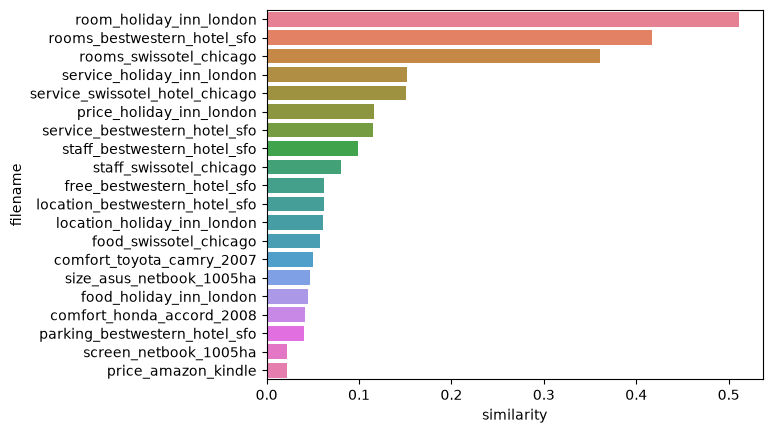

In [ ]:
# 기준 문서와 유사도 높은 기준 상위 20개 막대그래프 시각화 
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    x='similarity',  # x = 유사도
    y= 'filename',   # y = 파일명
    data= result_df.iloc[:20],  # 상위 20개
    hue= 'filename'  # 색상구분
)

plt.show()